# Prepare meteo data 2023 for submission

The 2m Lufft instrument was destroyed and not available between mid-October 2023 and April 2024. 
The Rotronic data are available for the entire period, but are not aggregated on the DWH (why not?). 
We will use the official hourly data from DWH where available and complement with our own aggregated Rotronic data where needed.

author: joerg.klausen@meteoswiss.ch

In [1]:
import os
import polars as pl
from processing.dwh import DWH

access_token = open(file="secrets-jretrieve", mode="r").read()
mkn = DWH(access_token=access_token, locationID="KEMKN")

DWH initialized.


In [2]:
metadata = {
    'prestah0': '2m pressure (QFE), Lufft (hPa)',
    'tre200h0': '2m temperature, Lufft',
    'ta2200h0': '2m temperature, Rotronic (°C)',
    'ure200h0': '2m relative humidity, Lufft (%)',
    'ua2200h0': '2m relative humidity, Rotronic (%)',
    'fkl010h0': '10m horizontal wind speed (m/s)',
    'dkl010h0': '10m horizontal wind direction (deg)',
    'rre150h0': '2m precipitation, Lufft (mm/h)',
    'gre000h0': '2m global radiation, Lufft (W/m2)',
    'txx200h0': 'combination of tre200h0 (up until 19 Oct 2024 09 UTC) and ta2200h0 (afterwards)',
    'uxx200h0': 'combination of ure200h0 (up until 19 Oct 2024 09 UTC) and ua2200h0 (afterwards)'
}

In [3]:
# get hourly values from MeteoSwiss DWH
parameter_short_names = "prestah0,tre200h0,ure200h0,fkl010h0,dkl010h0,rre150h0,gre000h0"
df = mkn.jretrieve(start="20230101000000", end="20240101000000", parameter_short_names=parameter_short_names)
display(df.describe())

statistic,station,termin,prestah0,tre200h0,ure200h0,fkl010h0,dkl010h0,rre150h0,gre000h0,dtm
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",7309.0,7309.0,5659.0,5653.0,5640.0,7292.0,7235.0,5619.0,5643.0,"""7309"""
"""null_count""",0.0,0.0,1650.0,1656.0,1669.0,17.0,74.0,1690.0,1666.0,"""0"""
"""mean""",10769.0,2.0231e13,661.703958,6.755563,70.163404,4.484202,164.729371,0.133992,195.220273,"""2023-07-12 03:…"
"""std""",0.0,3.6649e8,1.133786,2.492184,18.45749,2.601227,94.379702,1.449551,280.142282,null
"""min""",10769.0,2.0230e13,657.8,0.3,10.1,0.0,1.0,0.0,0.0,"""2023-01-01 00:…"
"""25%""",10769.0,2.0230e13,661.0,4.8,58.6,2.4,110.0,0.0,0.0,"""2023-04-19 02:…"
"""50%""",10769.0,2.0231e13,661.8,6.4,74.4,3.9,138.0,0.0,16.0,"""2023-07-18 02:…"
"""75%""",10769.0,2.0231e13,662.5,8.7,84.5,6.2,228.0,0.0,322.0,"""2023-10-11 00:…"
"""max""",10769.0,2.0240e13,665.2,13.8,99.9,18.8,360.0,43.5,1200.0,"""2024-01-01 00:…"


In [4]:
# get Rotronic data and RH data from 10m sensor from MeteoSwiss DWH and aggregate
parameter_short_names = "ta2200s0,ua2200s0,ua1200s0"
df2 = mkn.jretrieve(start="20230101000000", end="20240101000000", parameter_short_names=parameter_short_names)
display(df2.describe())

df2_1h = df2.sort(by='dtm').group_by_dynamic("dtm", every='1h').agg(pl.all().exclude(['dtm', 'termin', 'station']).mean())
df2_1h = df2_1h.rename({'ta2200s0': 'ta2200h0', 'ua2200s0': 'ua2200h0', 'ua1200s0': 'ua1200h0'})
display(df2_1h.describe())

statistic,station,termin,ta2200s0,ua2200s0,ua1200s0,dtm
str,f64,f64,f64,f64,f64,str
"""count""",43731.0,43731.0,43729.0,43408.0,43194.0,"""43731"""
"""null_count""",0.0,0.0,2.0,323.0,537.0,"""0"""
"""mean""",10769.0,2.0231e13,6.894416,76.768411,74.780622,"""2023-07-12 00:…"
"""std""",0.0,3.5247e8,2.518874,20.991861,19.465555,null
"""min""",10769.0,2.0230e13,-0.4,7.4,10.5,"""2023-01-01 00:…"
"""25%""",10769.0,2.0230e13,4.9,62.9,61.8,"""2023-04-18 23:…"
"""50%""",10769.0,2.0231e13,6.7,81.4,78.0,"""2023-07-17 21:…"
"""75%""",10769.0,2.0231e13,8.7,96.2,91.0,"""2023-10-10 15:…"
"""max""",10769.0,2.0240e13,16.0,100.0,100.0,"""2024-01-01 00:…"


statistic,dtm,ta2200h0,ua2200h0,ua1200h0
str,str,f64,f64,f64
"""count""","""7306""",7306.0,7280.0,7277.0
"""null_count""","""0""",0.0,26.0,29.0
"""mean""","""2023-07-12 01:…",6.897718,76.787512,74.890227
"""std""",null,2.45988,20.527659,19.044274
"""min""","""2023-01-01 00:…",0.2,9.05,10.7
"""25%""","""2023-04-19 01:…",4.95,63.35,62.35
"""50%""","""2023-07-17 22:…",6.7,81.45,78.3
"""75%""","""2023-10-10 16:…",8.7,94.95,90.516667
"""max""","""2024-01-01 00:…",14.133333,100.0,100.0


In [5]:
# combine dataframes, fill up xre200h0 data with xa2200ho data where needed, store as xxx200h0 columns
df_1h = pl.concat([df, df2_1h], how='align')
df_1h.drop_in_place('station')
df_1h.drop_in_place('termin')
df_1h = df_1h.with_columns(
            pl.when(pl.col('tre200h0').is_null())
                .then(pl.col('ta2200h0'))
                .otherwise(pl.col('tre200h0'))
            .alias('txx200h0'),
            pl.when(pl.col('ure200h0').is_null())
                .then(pl.col('ua2200h0'))
                .otherwise(pl.col('ure200h0'))
            .alias('uxx200h0'),
            )
df_1h = df_1h.select([pl.col('dtm'), pl.col('prestah0'), pl.col('txx200h0'), pl.col('uxx200h0'),
                      pl.col('fkl010h0'), pl.col('dkl010h0'), pl.col('gre000h0'), pl.col('rre150h0'),
                      pl.col('tre200h0'), pl.col('ure200h0'), pl.col('ta2200h0'), pl.col('ua2200h0'), pl.col('ua1200h0'),])
display(df_1h.describe())

statistic,dtm,prestah0,txx200h0,uxx200h0,fkl010h0,dkl010h0,gre000h0,rre150h0,tre200h0,ure200h0,ta2200h0,ua2200h0,ua1200h0
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""7334""",5659.0,7315.0,7303.0,7292.0,7235.0,5643.0,5619.0,5653.0,5640.0,7306.0,7280.0,7277.0
"""null_count""","""0""",1675.0,19.0,31.0,42.0,99.0,1691.0,1715.0,1681.0,1694.0,28.0,54.0,57.0
"""mean""","""2023-07-12 05:…",661.703958,6.886616,74.119938,4.484202,164.729371,195.220273,0.133992,6.755563,70.163404,6.897718,76.787512,74.890227
"""std""",null,1.133786,2.403951,19.175267,2.601227,94.379702,280.142282,1.449551,2.492184,18.45749,2.45988,20.527659,19.044274
"""min""","""2023-01-01 00:…",657.8,0.3,10.1,0.0,1.0,0.0,0.0,0.3,10.1,0.2,9.05,10.7
"""25%""","""2023-04-19 03:…",661.0,5.0,62.1,2.4,110.0,0.0,0.0,4.8,58.6,4.95,63.35,62.35
"""50%""","""2023-07-18 04:…",661.8,6.683333,77.766667,3.9,138.0,16.0,0.0,6.4,74.4,6.7,81.45,78.3
"""75%""","""2023-10-11 02:…",662.5,8.7,88.783333,6.2,228.0,322.0,0.0,8.7,84.5,8.7,94.95,90.516667
"""max""","""2024-01-01 00:…",665.2,13.8,100.0,18.8,360.0,1200.0,43.5,13.8,99.9,14.133333,100.0,100.0


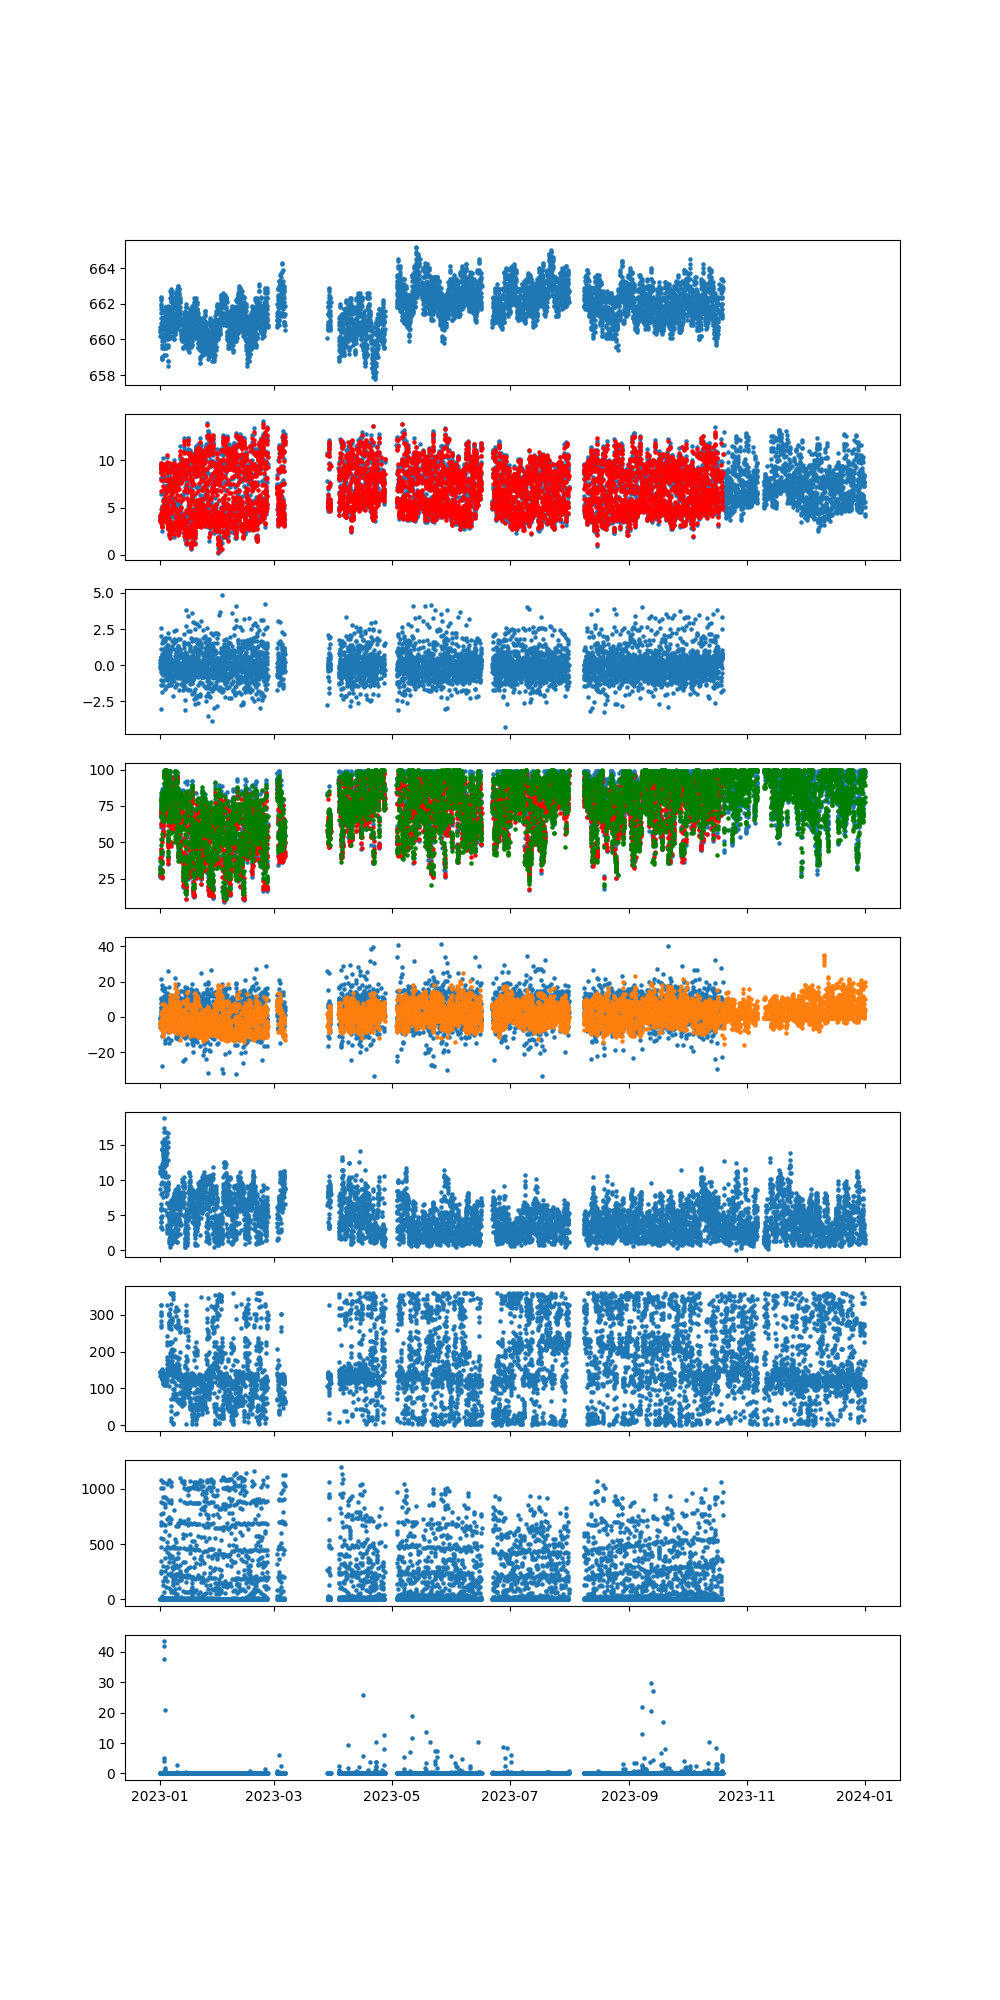

In [6]:
# plot data
import matplotlib.pyplot as plt
%matplotlib widget

fig, axs = plt.subplots(figsize=(10, 20), nrows=9, sharex=True)
axs[0].scatter(x=df_1h['dtm'], y=df_1h['prestah0'], s=5)
axs[1].scatter(x=df_1h['dtm'], y=df_1h['ta2200h0'], s=5)
axs[1].scatter(x=df_1h['dtm'], y=df_1h['tre200h0'], s=5, c='red')
axs[2].scatter(x=df_1h['dtm'], y=df_1h['ta2200h0']-df_1h['tre200h0'], s=5)
axs[3].scatter(x=df_1h['dtm'], y=df_1h['ua2200h0'], s=5)
axs[3].scatter(x=df_1h['dtm'], y=df_1h['ure200h0'], s=5, c='red')
axs[3].scatter(x=df_1h['dtm'], y=df_1h['ua1200h0'], s=5, c='green')
axs[4].scatter(x=df_1h['dtm'], y=df_1h['ua2200h0']-df_1h['ure200h0'], s=5)
axs[4].scatter(x=df_1h['dtm'], y=df_1h['ua2200h0']-df_1h['ua1200h0'], s=5)
axs[5].scatter(x=df_1h['dtm'], y=df_1h['fkl010h0'], s=5)
axs[6].scatter(x=df_1h['dtm'], y=df_1h['dkl010h0'], s=5)
axs[7].scatter(x=df_1h['dtm'], y=df_1h['gre000h0'], s=5)
axs[8].scatter(x=df_1h['dtm'], y=df_1h['rre150h0'], s=5)

In [8]:
# drop original columns, retain combined columns, save to file
df_1h.drop_in_place('tre200h0')
df_1h.drop_in_place('ta2200h0')
df_1h.drop_in_place('ure200h0')
df_1h.drop_in_place('ua2200h0')
df_1h.drop_in_place('ua1200h0')
display(df_1h.describe())

path = "data/level2/2023"
file = "mkn_meteo_1h"
df_1h.write_parquet(os.path.join(path, f"{file}.parquet"))
df_1h.write_csv(os.path.join(path, f"{file}.csv"))

statistic,dtm,prestah0,txx200h0,uxx200h0,fkl010h0,dkl010h0,gre000h0,rre150h0
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""7334""",5659.0,7315.0,7303.0,7292.0,7235.0,5643.0,5619.0
"""null_count""","""0""",1675.0,19.0,31.0,42.0,99.0,1691.0,1715.0
"""mean""","""2023-07-12 05:…",661.703958,6.886616,74.119938,4.484202,164.729371,195.220273,0.133992
"""std""",null,1.133786,2.403951,19.175267,2.601227,94.379702,280.142282,1.449551
"""min""","""2023-01-01 00:…",657.8,0.3,10.1,0.0,1.0,0.0,0.0
"""25%""","""2023-04-19 03:…",661.0,5.0,62.1,2.4,110.0,0.0,0.0
"""50%""","""2023-07-18 04:…",661.8,6.683333,77.766667,3.9,138.0,16.0,0.0
"""75%""","""2023-10-11 02:…",662.5,8.7,88.783333,6.2,228.0,322.0,0.0
"""max""","""2024-01-01 00:…",665.2,13.8,100.0,18.8,360.0,1200.0,43.5


In [9]:
# add metadata file
import json
with open(file=os.path.join(path, f"{file}.json"), mode='w') as fh:
    fh.write(json.dumps(metadata))

In [10]:
# load data from .parquet file. These are the data compiled from the original bulletins
# file = "data/level2/2023/vrxa00.parquet"
# df2 = pl.read_parquet(file)
# vrxa00_stats = df2.describe()
# vrxa00_stats